In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
delhi_df = pd.read_csv("../data/processed/charging_sessions.csv")

## peak time

In [3]:
delhi_df["Start_Hour"].value_counts().sort_index()

Start_Hour
6     5
7     4
8     5
10    3
11    5
12    3
13    2
14    4
15    4
16    7
17    4
18    5
19    5
20    2
Name: count, dtype: int64

In [4]:
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

delhi_df["Time_of_Day"] = delhi_df["Start_Hour"].apply(get_time_of_day)

In [5]:
delhi_df["Time_of_Day"].value_counts()

Time_of_Day
Morning      22
Afternoon    20
Evening      16
Name: count, dtype: int64

In [6]:
delhi_df.columns

Index(['Station_ID', 'City', 'Date', 'Vehicle_Type', 'Charging_Start_Time',
       'Charging_End_Time', 'Energy_Consumed_kWh', 'Cost_INR',
       'Payment_Method', 'Charging_Start', 'Charging_End',
       'Session_Duration_Minutes', 'Start_Hour', 'End_Hour', 'Day_of_Week',
       'Is_Weekend', 'Month', 'supports_2W', 'supports_3W', 'supports_4W',
       'Time_of_Day'],
      dtype='str')

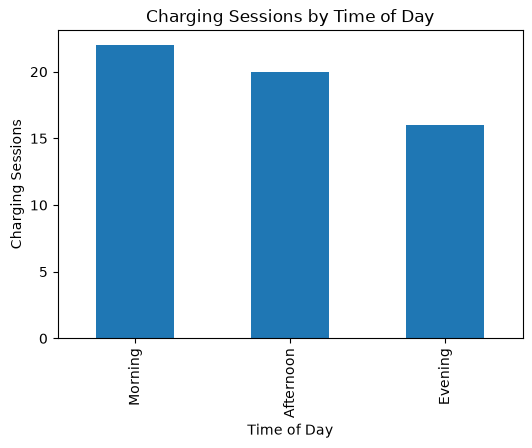

In [7]:
delhi_df["Time_of_Day"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.xlabel("Time of Day")
plt.ylabel("Charging Sessions")
plt.title("Charging Sessions by Time of Day")
plt.show()

In [8]:
delhi_df.groupby("Time_of_Day")["Session_Duration_Minutes"].agg(["count", "mean", "median", "max"])

,count,mean,median,max
Time_of_Day,,,,
Afternoon,20,101.900,100.0,176.0
Evening,16,114.625,124.5,179.0
Morning,22,105.000,104.0,160.0


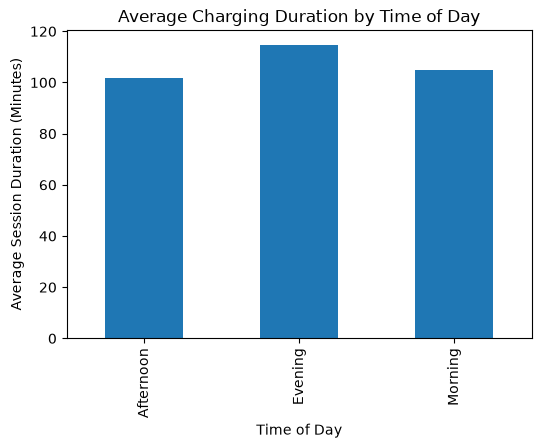

In [9]:
avg_duration = delhi_df.groupby("Time_of_Day")["Session_Duration_Minutes"].mean()

avg_duration.plot(kind="bar", figsize=(6,4))

plt.xlabel("Time of Day")
plt.ylabel("Average Session Duration (Minutes)")
plt.title("Average Charging Duration by Time of Day")
plt.show()

In [10]:
delhi_df.groupby("Time_of_Day")["Energy_Consumed_kWh"].agg(["mean", "median", "max"])

,mean,median,max
Time_of_Day,,,
Afternoon,49.290000,42.90,99.5
Evening,67.375000,78.05,97.5
Morning,64.495455,73.65,99.3


In [11]:
delhi_df.groupby("Time_of_Day")["Vehicle_Type"].value_counts()

Time_of_Day  Vehicle_Type
Afternoon    Bike            7
             Truck           7
             Car             4
             Bus             2
Evening      Car             5
             Truck           4
             Bike            4
             Bus             3
Morning      Bus             6
             Car             6
             Truck           5
             Bike            5
Name: count, dtype: int64

### Demand Pattern Learning Summary

- **Morning** recorded the highest number of charging sessions (22), indicating higher charging demand during the early part of the day.
- **Evening** sessions had the **longest average charging duration (114.6 minutes)** and the **highest average energy consumption (67.38 kWh)**, suggesting that chargers remain occupied for longer periods.
- **Afternoon** sessions showed the **lowest average energy consumption (49.29 kWh)** and slightly shorter charging durations, indicating comparatively lower charging intensity.
- The vehicle composition varied across different times of the day. Morning sessions had a balanced mix of buses, cars, trucks, and bikes, while afternoon sessions were dominated by bikes and trucks, and evening sessions primarily consisted of cars and trucks.

In [12]:
demand_df = (
    delhi_df
    .groupby("Time_of_Day")
    .agg(
        sessions=("Time_of_Day", "count"),
        avg_duration=("Session_Duration_Minutes", "mean"),
        avg_energy=("Energy_Consumed_kWh", "mean")
    )
)

demand_df

,sessions,avg_duration,avg_energy
Time_of_Day,,,
Afternoon,20,101.900,49.290000
Evening,16,114.625,67.375000
Morning,22,105.000,64.495455


In [13]:
for col in ["sessions", "avg_duration", "avg_energy"]:
    demand_df[col + "_norm"] = (
        demand_df[col] - demand_df[col].min()
    ) / (
        demand_df[col].max() - demand_df[col].min()
    )
demand_df


,sessions,avg_duration,avg_energy,sessions_norm,avg_duration_norm,avg_energy_norm
Time_of_Day,,,,,,
Afternoon,20,101.900,49.290000,0.666667,0.000000,0.000000
Evening,16,114.625,67.375000,0.000000,1.000000,1.000000
Morning,22,105.000,64.495455,1.000000,0.243615,0.840777


In [14]:
demand_df["Demand_Score"] = (
    0.3 * demand_df["sessions_norm"] +
    0.4 * demand_df["avg_duration_norm"] +
    0.3 * demand_df["avg_energy_norm"]
) 
demand_df

,sessions,avg_duration,avg_energy,sessions_norm,avg_duration_norm,avg_energy_norm,Demand_Score
Time_of_Day,,,,,,,
Afternoon,20,101.900,49.290000,0.666667,0.000000,0.000000,0.200000
Evening,16,114.625,67.375000,0.000000,1.000000,1.000000,0.700000
Morning,22,105.000,64.495455,1.000000,0.243615,0.840777,0.649679


In [15]:
demand_df.loc["Night"] = {
    "sessions": 0,
    "avg_duration": 0,
    "avg_energy": 0,
    "sessions_norm": 0,
    "avg_duration_norm": 0,
    "avg_energy_norm": 0,
    "Demand_Score": 0
}

In [16]:
demand_df.to_csv(
    "../data/processed/demand_profile.csv",
    index=True
)